<a href="https://colab.research.google.com/github/danialbunyamin/customer-churn-telecom/blob/main/Customer_Churn_portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Telecom Customer Churn Prediction: Exploratory Analysis and Machine Learning**

**I. Introduction**

Customer churn is one of the key challenges faced by telecommunications companies. Losing existing customers can have a significant impact on revenue and business growth, while acquiring new customers is often more costly than retaining existing ones.

In a highly competitive telecommunications market, understanding why customers leave and identifying customers who are likely to churn can help companies take proactive retention actions.

This project focuses on analyzing customer data to identify patterns and factors associated with customer churn and developing machine learning models to predict whether a customer is likely to leave the company.

**II. Business Problem**

The telecommunications company wants to reduce customer churn by identifying customers who have a higher probability of leaving.

The main questions addressed in this project are:

- What factors are associated with customer churn?
- What characteristics distinguish customers who churn from those who remain?
- Can customer churn be predicted using machine learning?
- Which classification model provides the best performance?
- How can the model's predictions support customer retention strategies?

**III. Project Objectives**

The main objectives of this project are to:

- Explore and understand customer characteristics and churn patterns.
- Clean and preprocess the dataset for machine learning.
- Identify important factors that may influence customer churn.
- Build and evaluate several classification models.
- Address potential class imbalance using oversampling techniques.
- Compare model performance using metrics such as Accuracy, Precision, Recall, F1 Score, F2 Score, and ROC AUC.
- Select the most appropriate model based on the business objective.

**IV. Analytical Approach**

The analysis follows these main stages:

Data Understanding → Data Cleaning → Exploratory Data Analysis → Feature Engineering → Data Preprocessing → Model Development → Model Evaluation → Oversampling → Model Comparison → Business Insights

Several classification algorithms are evaluated, including:

- Logistic Regression
- Decision Tree
- Random Forest

Because identifying customers who are likely to churn is particularly important, the analysis does not rely solely on Accuracy. Recall, F1 Score, F2 Score, and ROC AUC are also considered when evaluating model performance.

**V. Business Impact**

A reliable churn prediction model can help the company move from a reactive approach to a more proactive customer retention strategy.

By identifying customers with a higher likelihood of churn, the company can potentially:

- Prioritize high-risk customers for retention campaigns.
- Investigate factors contributing to customer dissatisfaction.
- Develop targeted offers or services for at-risk customers.
- Improve customer experience and satisfaction.
- Reduce customer loss and protect recurring revenue.

# 1. Import relevant libraries

In [ ]:
# Step 1: Import relevant libraries---------------------------------------------------------

#Standard libraries for data analysis:----------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm, skew


# sklearn modules for data preprocessing-------------------------------------

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#sklearn modules for Model Selection--------------------------------------

from sklearn import svm, tree, linear_model, neighbors
from sklearn import naive_bayes, ensemble, discriminant_analysis, gaussian_process
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


#sklearn modules for Model Evaluation & Improvement---------------------------

from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, fbeta_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score, GridSearchCV, ShuffleSplit, KFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve



#Standard libraries for data visualization---------------------

import seaborn as sn
from matplotlib import pyplot
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib
%matplotlib inline
color = sn.color_palette()
import matplotlib.ticker as mtick
from IPython.display import display
pd.options.display.max_columns = None
from pandas.plotting import scatter_matrix






# 2. Set Up the current working directory & Import Dataset

In [ ]:
# Step 2: Import the dataset
dataset = pd.read_csv('/content/customer_churn_data.csv')

#Step 3: Read Dataset
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Column Descriptions

#### 1. Demographics & Customer Profile


    * customerID: A unique alphanumeric ID assigned to each customer.

    * gender: Whether the customer is male or female.

    * SeniorCitizen: Indicates if the customer is a senior citizen (1 for Yes, 0 for No).

    * Partner: Indicates whether the customer has a partner (Yes or No).

    * Dependents: Indicates whether the customer has financial dependents, such as children (Yes or No).


#### 2. Subscribed Services

    * tenure: The number of months the customer has stayed with the company.

    * PhoneService: Indicates if the customer has a home phone service (Yes or No).

    * MultipleLines: Indicates if the customer has multiple phone lines (Yes, No, or No phone service).

    * InternetService: The customer’s internet service provider type (DSL, Fiber optic, or No).

    * OnlineSecurity: Indicates if the customer has online security add-on (Yes, No, or No internet service).

    * OnlineBackup: Indicates if the customer has an online backup service (Yes, No, or No internet service).

    * DeviceProtection: Indicates if the customer has tech device protection plan (Yes, No, or No internet service).

    * TechSupport: Indicates if the customer has premium technical support (Yes, No, or No internet service).

    * StreamingTV: Indicates if the customer uses the TV streaming service (Yes, No, or No internet service).

    * StreamingMovies: Indicates if the customer uses the movie streaming service (Yes, No, or No internet service).
    
    
#### 3. Account & Financial Information

    * Contract: The contract term of the customer (Month-to-month, One year, Two year).

    * PaperlessBilling: Indicates if the customer has chosen paperless billing (Yes or No).

    * PaymentMethod: The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)).

    * MonthlyCharges: The amount charged to the customer monthly.

    * TotalCharges: The total amount charged to the customer over their entire tenure.

#### 4. Target Variable

    * Churn: Indicates whether the customer left the company within the last month (Yes or No). This is the primary dependent variable you aim to analyze or predict.


# 4. Evaluate Data Structure

In [ ]:
# Step 4: Evaluate data structure
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
dataset.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
#Recheck Column Datatypes:
col_dtypes = dataset.columns.to_series().groupby(dataset.dtypes).groups

for col, value in col_dtypes.items():
    print(col)
    print(value)
    print('\n')

int64
Index(['SeniorCitizen', 'tenure'], dtype='object')


float64
Index(['MonthlyCharges'], dtype='object')


object
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')




In [ ]:
#Check missing value
dataset.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Overview:

The dataset contains no missing values.

In [ ]:
#Unique values in each categorical variable:
print(dataset['PaymentMethod'].nunique())
dataset['PaymentMethod'].unique()



4


array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [ ]:
print(dataset['Contract'].nunique())
dataset['Contract'].unique()

3


array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
print(dataset['TotalCharges'].nunique())
dataset['TotalCharges'].unique()

6531


array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

# 5. Analyzing Target Variable Distribution

In [ ]:
#Step 5: Check Target Variable Distribution -----------------------------------------------

dataset["Churn"].value_counts()


,count
Churn,
No,5174
Yes,1869


In [ ]:
#Step 5: Check Target Variable Distribution -----------------------------------------------

dataset["Churn"].value_counts(normalize=True)


,proportion
Churn,
No,0.73463
Yes,0.26537


Analysis:

The dataset exhibits class imbalance, with non-churned customers outnumbering churned customers.

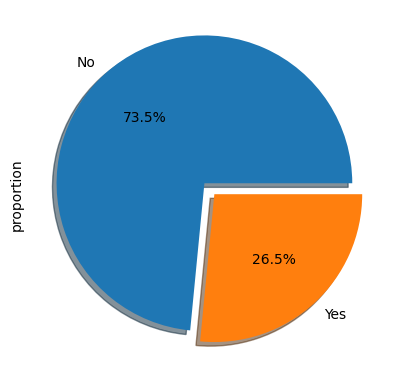

In [ ]:
explode_list = [0.1, 0]

(
    dataset['Churn']
    .value_counts(normalize=True)
    .plot(
        kind='pie',
        autopct='%1.1f%%',
        explode=explode_list,
        shadow=True
        )
);

# 6. Clean the Dataset

In [ ]:
dataset['TotalCharges'].head()

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


In [ ]:
#Step 6: Clean the Dataset----------------------------------------------------------------------
df_cleaned = dataset.copy()
df_cleaned['TotalCharges'] = pd.to_numeric(df_cleaned['TotalCharges'], errors='coerce')
df_cleaned['TotalCharges'] = df_cleaned['TotalCharges'].astype('float')

In [ ]:
df_cleaned.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#Step 7: Take care of missing data---------------------------------------------------------------
# Find the average/median and fill missing values of each columns programmatically
df_cleaned2 = df_cleaned.copy()
na_cols = df_cleaned2.isna().any()
na_cols = na_cols[na_cols == True].reset_index()
na_cols = na_cols["index"].to_list()

for col in dataset.columns[1:]:
  if col in na_cols:
    if df_cleaned2[col].dtype != 'object':
        df_cleaned2[col] = df_cleaned2[col].fillna(df_cleaned2[col].mean()).round(0)
    else:
          mode_value = df_cleaned2[col].mode()[0]
          df_cleaned2[col] = df_cleaned2[col].fillna(mode_value)

***Code Explanation: Automated Missing Data Handling***

This script programmatically identifies and imputes missing values (NaN) across all features in the dataset while preserving raw data integrity.

In [ ]:
df_cleaned2.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# 8. Apply label encoding to binary columns

In [ ]:
#Step 8: label Encode Binary data----------------------------------------------------------------
df_labeled = df_cleaned2.copy()
#Create a label encoder object
le = LabelEncoder()
encoders = {}
# Label Encoding will be used for columns with 2 or less unique values
le_count = 0
for col in df_labeled.columns:
    if df_labeled[col].dtype == 'object':
        if len(list(df_labeled[col].unique())) <= 2:
            print(col)
            le.fit(df_labeled[col])
            df_labeled[col] = le.transform(df_labeled[col])
            encoders[col] = le.classes_
            le_count += 1
print('%d columns were label binary-encoded.' % le_count)


gender
Partner
Dependents
PhoneService
PaperlessBilling
Churn
6 columns were label binary-encoded.


***Code Note: Binary Label Encoding***

This snippet applies Label Encoding exclusively to categorical features with 2 or fewer unique values (e.g., Yes/No, Male/Female), converting them into numeric binary format (0 and 1).

In [ ]:
df_labeled.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,30.0,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1890.0,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.0,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1841.0,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,152.0,1


# 9. Exploratory Data Analysis

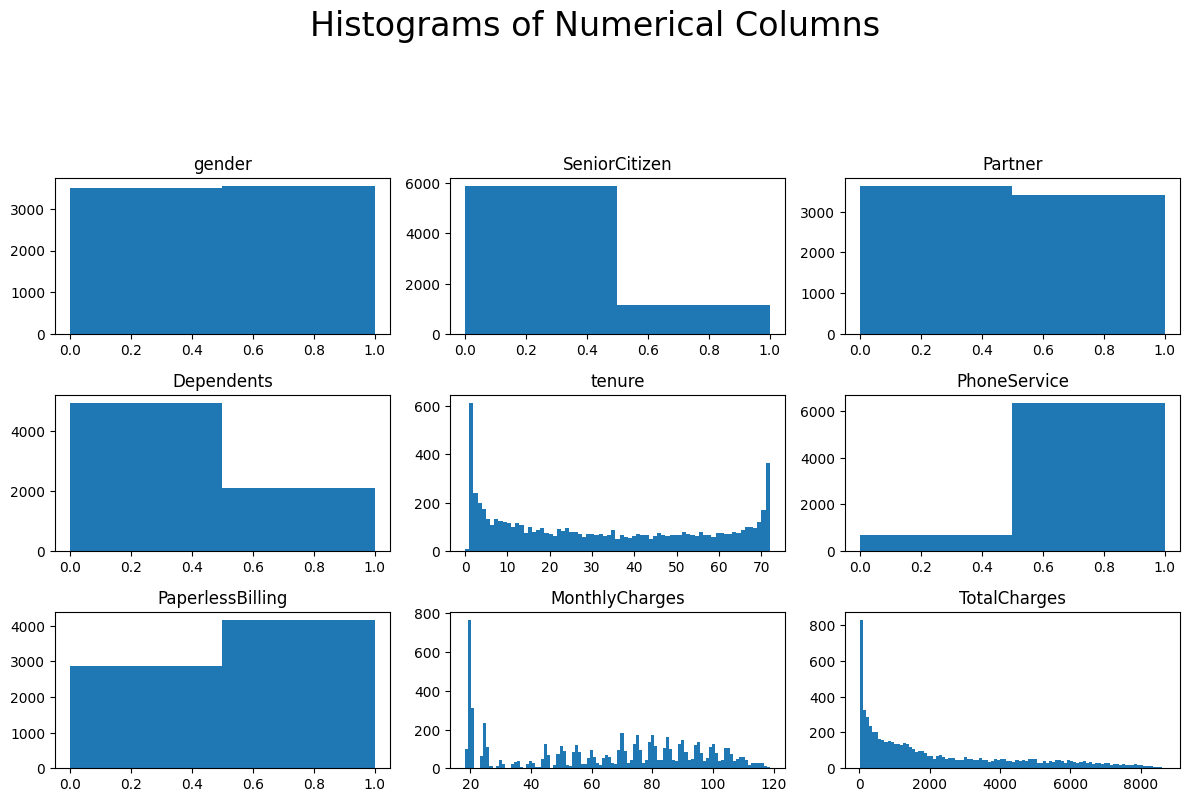

In [ ]:
#Step 9: Exploratory Data Analysis----------------------------------------------------------------------

#Step 9.1. Plot Histogram of numeric Columns--------------------------------------

dataset2 = df_labeled[
    [
        'gender',
        'SeniorCitizen',
        'Partner',
        'Dependents',
        'tenure',
        'PhoneService',
        'PaperlessBilling',
        'MonthlyCharges',
        'TotalCharges'
    ]
]
#Histogram:

fig = plt.figure(figsize=(12, 15))
plt.suptitle(
    'Histograms of Numerical Columns\n',
    horizontalalignment="center",
    fontstyle = "normal",
    fontsize = 24,
    fontfamily = "sans-serif"
)

for i in range(dataset2.shape[1]):
    plt.subplot(6, 3, i + 1)
    f = plt.gca()
    f.set_title(dataset2.columns.values[i])

    vals = np.size(dataset2.iloc[:, i].unique())
    if vals >= 100:
        vals = 100

    plt.hist(dataset2.iloc[:, i], bins=vals)#, color = '#ec838a')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

***Visualizations Analysis***
1. Majority of customers are non-senior citizens and have no dependents.
2. A high number of customers have low tenure, which may be associated with higher churn.
3. A large portion of customers use phone services and prefer paperless billing.
4. Monthly charges show a varied distribution, with a significant concentration of customers in the low-to-mid range.
5. Total charges increase over time, alongside an influx of new customers.


In [ ]:
df_labeled['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

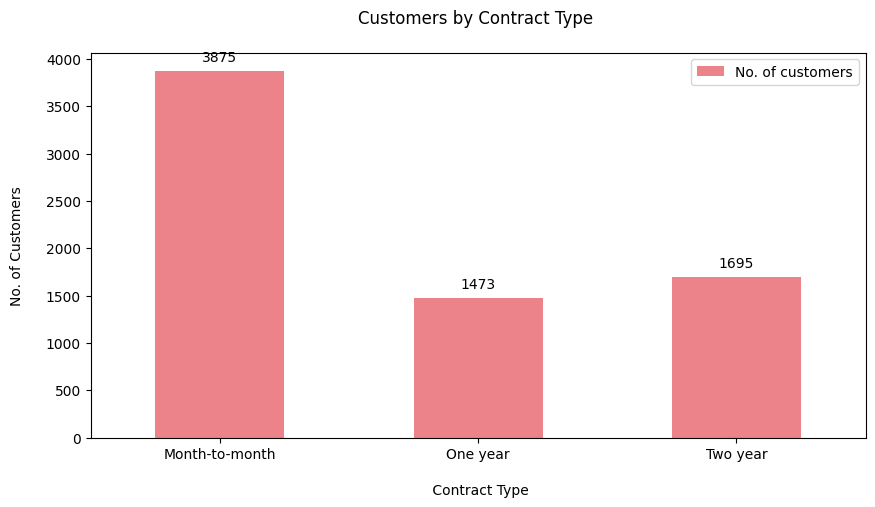

In [ ]:
#Step 9.2. Analyze distribution of Key Categorical Variables---------------------------------------------


#(1) Distribution of Contract Type----------------------------------------------------------------------------------------

contract_split = df_labeled[[ "customerID", "Contract"]]
sectors = contract_split .groupby ("Contract")
contract_split = pd.DataFrame(sectors["customerID"].count())
contract_split.rename(columns={'customerID':'No. of customers'}, inplace=True)


ax =  (
    contract_split[["No. of customers"]]
    .plot.bar(
        title = 'Customers by Contract Type',
        legend =True,
        table = False,
        grid = False,
        subplots = False,
        figsize =(10, 5),
        color ='#ec838a',
        stacked=False
        )
)

plt.ylabel('No. of Customers\n',horizontalalignment="center",fontstyle = "normal", fontfamily = "sans-serif")
plt.xlabel('\n Contract Type',horizontalalignment="center",fontstyle = "normal", fontfamily = "sans-serif")
plt.title('Customers by Contract Type \n',horizontalalignment="center", fontstyle = "normal", fontfamily = "sans-serif")
plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(contract_split[["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax)

***Executive Summary***
* Dominance of Short-Term Contracts: Over 50% of customers (3,875) opt for month-to-month plans, making them the largest segment.
* Low Long-Term Retention: Long-term contracts represent a smaller portion of the user base, with 1,473 customers on one-year plans and 1,695 on two-year plans.
* Business Implication: The high proportion of month-to-month subscriptions increases vulnerability to customer attrition, suggesting a need for strategies that incentivize users to switch to long-term commitments.

***Conclusion:***
The customer base is heavily skewed toward short-term commitments, with the majority enrolled in month-to-month contracts. This indicates a potential churn risk, as customers on short-term contracts can leave the service more easily compared to those on long-term contracts.

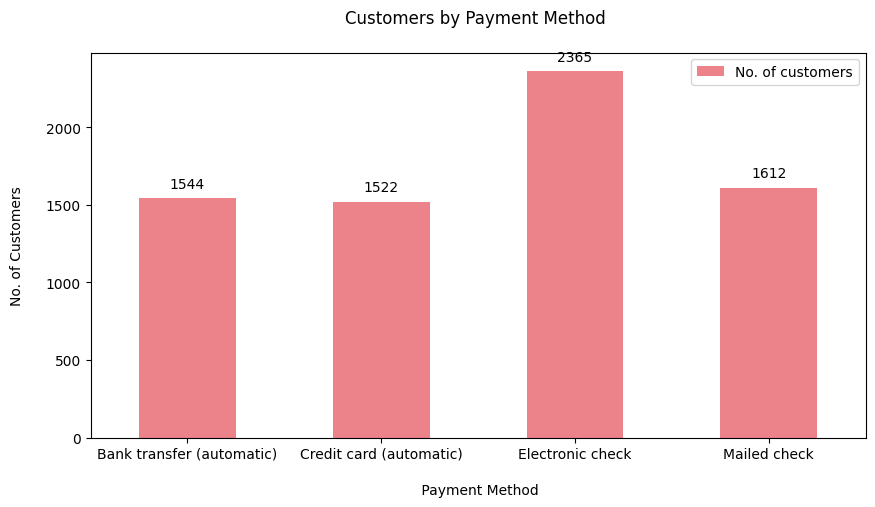

In [ ]:
#(2) Distribution of Payment Method Type---------------------------------------------------------------------------------------

payment_method_split = df_labeled[[ "customerID", "PaymentMethod"]]
sectors = payment_method_split  .groupby ("PaymentMethod")
payment_method_split  = pd.DataFrame(sectors["customerID"].count())
payment_method_split.rename(columns={'customerID':'No. of customers'}, inplace=True)


ax =  payment_method_split [["No. of customers"]].plot.bar(title = 'Customers by Payment Method', legend =True, table = False, grid = False,  subplots = False,  figsize =(10, 5), color ='#ec838a', stacked=False)

plt.ylabel('No. of Customers\n',horizontalalignment="center",fontstyle = "normal", fontfamily = "sans-serif")
plt.xlabel('\n Payment Method',horizontalalignment="center",fontstyle = "normal", fontfamily = "sans-serif")
plt.title('Customers by Payment Method \n',horizontalalignment="center", fontstyle = "normal", fontfamily = "sans-serif")
plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(payment_method_split [["No. of customers"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax)

***Payment Method Distribution Analysis***
- Dominance of Electronic Check: Electronic check is the most preferred payment method, accounting for the highest number of customers at 2,365.

- Even Spread Across Other Methods: The remaining payment methods show a relatively balanced distribution:
    *   Mailed check: 1,612 customers
    *   Bank transfer (automatic): 1,544 customers
    *   Credit card (automatic): 1,522 customers

- Automatic vs. Manual Payments: Non-automatic payment methods (Electronic check & Mailed check) make up the majority of the customer base compared to automated payment options (Bank transfer & Credit card).





***Insight:***

The high reliance on electronic check is notable because, in churn analysis, customers using manual payment methods—especially electronic checks—often exhibit higher churn rates compared to those on automated payments (Bank transfer or Credit card). Encouraging customers to migrate to automatic payment options could be a key strategy for improving retention.

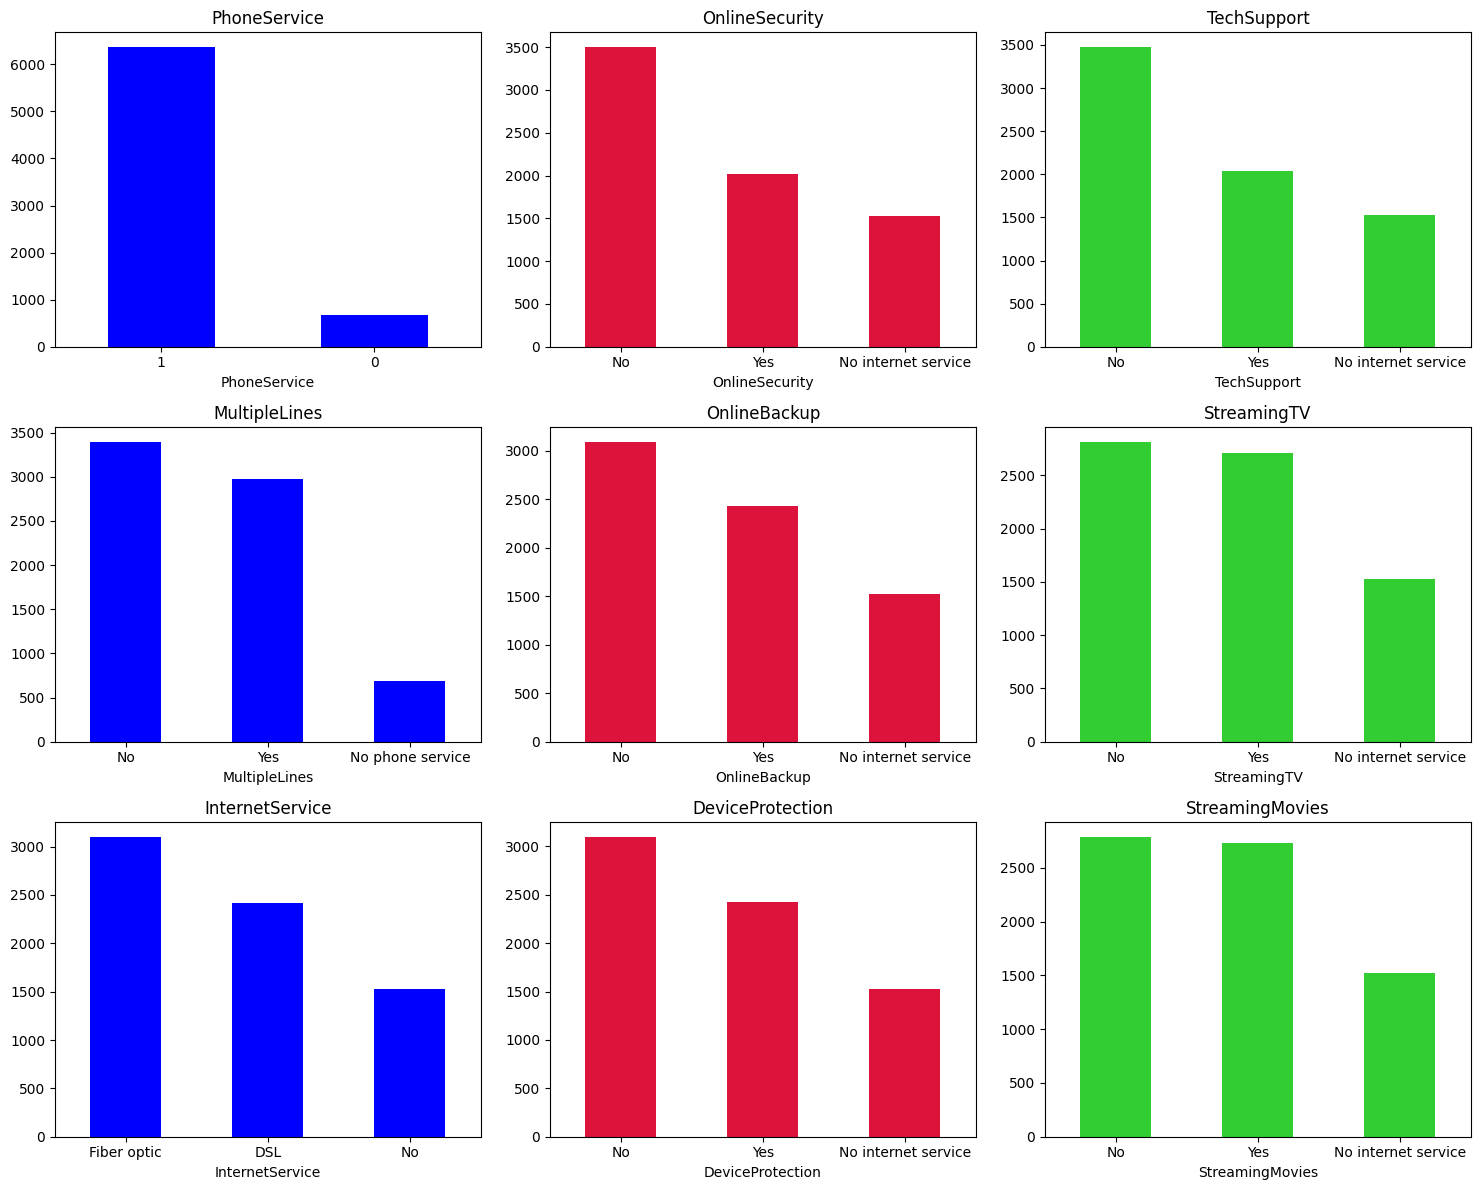

In [ ]:
#(3) Distribution of various Label Encoded Categorical Variables---------------------------------------------------------------------------------------

services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
           'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

fig, axes = plt.subplots(nrows = 3,ncols = 3,figsize = (15,12))
for i, item in enumerate(services):
    if i < 3:
        ax = df_labeled[item].value_counts().plot(kind = 'bar',ax=axes[i,0],rot = 0, color ='#0000FF' )

    elif i >=3 and i < 6:
        ax = df_labeled[item].value_counts().plot(kind = 'bar',ax=axes[i-3,1],rot = 0,color ='#DC143C')

    elif i < 9:
        ax = df_labeled[item].value_counts().plot(kind = 'bar',ax=axes[i-6,2],rot = 0,color = '#32CD32')
    ax.set_title(item)
plt.tight_layout()

***Services & Add-ons Analysis***
1. **Upselling Opportunities**: A significant number of customers currently do not use add-on services such as Online Security, Online Backup, or Device Protection. The company could introduce bundled packages or promotional offers to drive adoption of these features.
2. **Impact on Churn:** Further analysis is required to determine whether customers without add-on services exhibit a higher churn rate compared to those subscribed to a full service suite.
3. **Tech Support Adoption**: Low subscription rates for Tech Support may lead to higher churn if customers encounter unaddressed technical issues. Introducing promotional discounts or educational campaigns could help boost enrollment.
4. **Streaming Services Marketing:** Targeted marketing strategies can be leveraged to convert non-streaming users—particularly those who already have an active internet plan but have not yet adopted streaming add-ons.

In [ ]:
#Step 9.3: Analyze Churn Rate by Categorical variables:   -------------------------------------------------------------

#(1) Overall Churn Rate------------------------------------------------------------------------------------------



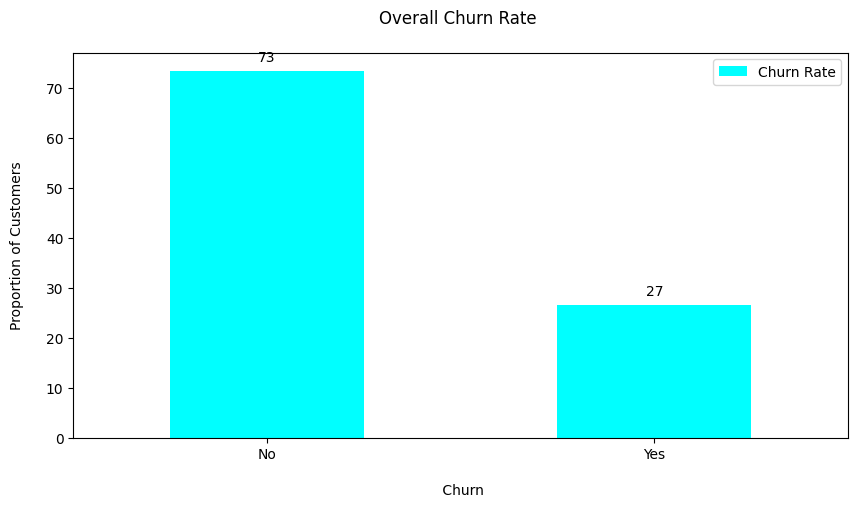

In [ ]:
import matplotlib.ticker as mtick
churn_rate = df_labeled[['Churn','customerID']].copy()
churn_rate['churn_label'] = pd.Series(np.where(churn_rate['Churn'] == 0, 'No', 'Yes'))

sectors = churn_rate.groupby('churn_label')
churn_rate = pd.DataFrame(sectors['customerID'].count())
churn_rate["Churn Rate"] = (churn_rate["customerID"]/sum(churn_rate["customerID"]))*100
ax = churn_rate[["Churn Rate"]].plot.bar(title = 'Overall Churn Rate', legend =True, table = False, grid = False,  subplots = False,  figsize =(10, 5), color ='#00FFFF')

plt.ylabel('Proportion of Customers\n', horizontalalignment="center", fontstyle = "normal", fontfamily = "sans-serif")
plt.xlabel('\n Churn', horizontalalignment="center", fontstyle = "normal", fontfamily = "sans-serif")
plt.title('Overall Churn Rate \n', horizontalalignment="center", fontstyle = "normal", fontfamily = "sans-serif")
plt.legend(loc='upper right')
plt.xticks(rotation=0, horizontalalignment="center")
plt.yticks(rotation=0, horizontalalignment="right")

x_labels = np.array(churn_rate[["customerID"]])

def add_value_labels(ax, spacing=5):
    for rect in ax.patches:
        y_value = rect.get_height()
        x_value = rect.get_x() + rect.get_width() / 2
        space = spacing
        va = 'bottom'
        if y_value < 0:
            space *= -1
            va = 'top'
        label = "{:.0f}".format(y_value)
        ax.annotate(
            label,
            (x_value, y_value),
            xytext=(0, space),
            textcoords="offset points",
            ha='center',
            va=va)
add_value_labels(ax);


In [ ]:
df_labeled[['Contract', 'Churn']].value_counts()

Contract        Churn
Month-to-month  0        2220
                1        1655
Two year        0        1647
One year        0        1307
                1         166
Two year        1          48
Name: count, dtype: int64

In [ ]:

# Membuat fungsi yang menghasilkan pie chart untuk membandingkan distribusi "Churn" berdasarkan kategori
def plot_churn_by_category(dataset, categorical_col):

    categories = dataset[categorical_col].unique()
    num_subplots = len(categories)

    # Buat subplots
    fig, axes = plt.subplots(1, num_subplots, figsize=(5 * num_subplots, 5))

    # Jika hanya satu subplot, ubah menjadi list agar iterable
    if num_subplots == 1:
        axes = [axes]

    for i, category in enumerate(categories):
        subset = dataset[dataset[categorical_col] == category]
        churn_counts = subset['Churn'].value_counts()

        # Buat pie chart
        churn_counts.plot(
            kind='pie',
            ax=axes[i],
            autopct='%1.1f%%',
            shadow=True,
            startangle=90
        )
        axes[i].set_title(f'Churn for {category} in {categorical_col}')
        axes[i].set_ylabel('')

    # Atur layout dan judul utama
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f'Churn Distribution by {categorical_col}', fontsize=16)

    plt.show()


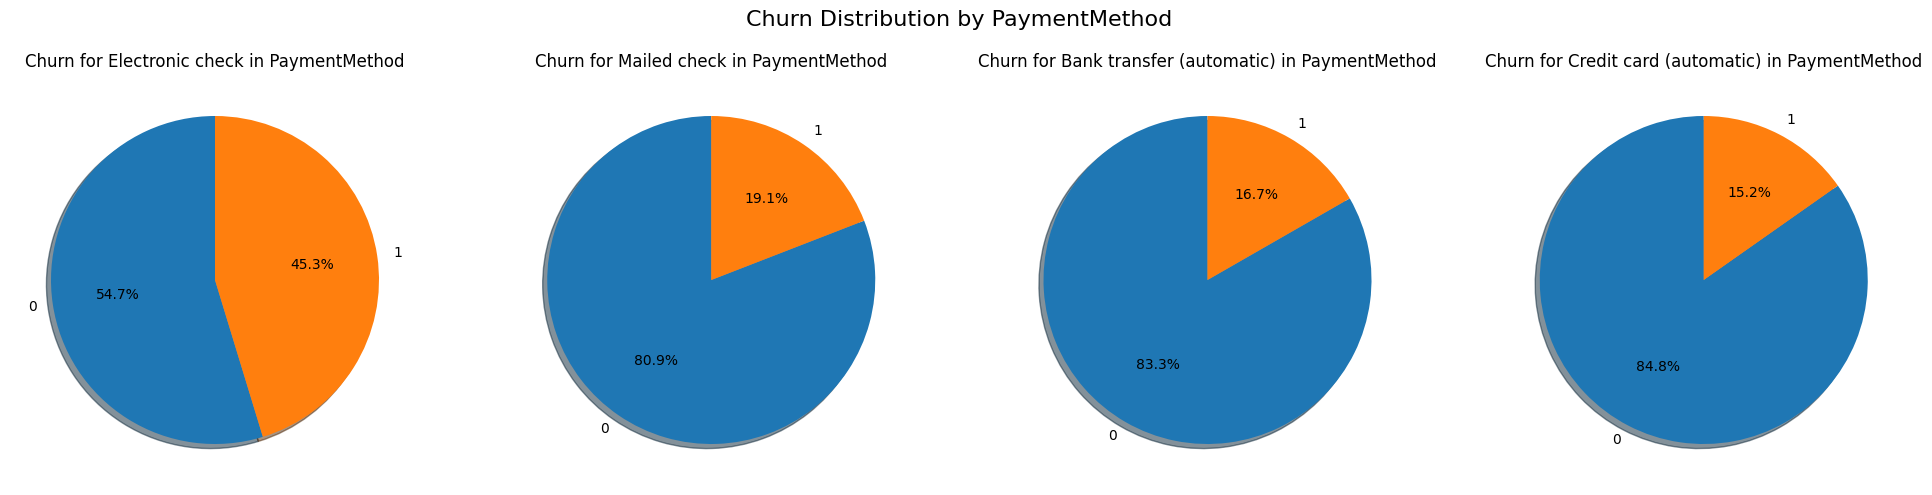

In [ ]:
plot_churn_by_category(df_labeled, 'PaymentMethod')

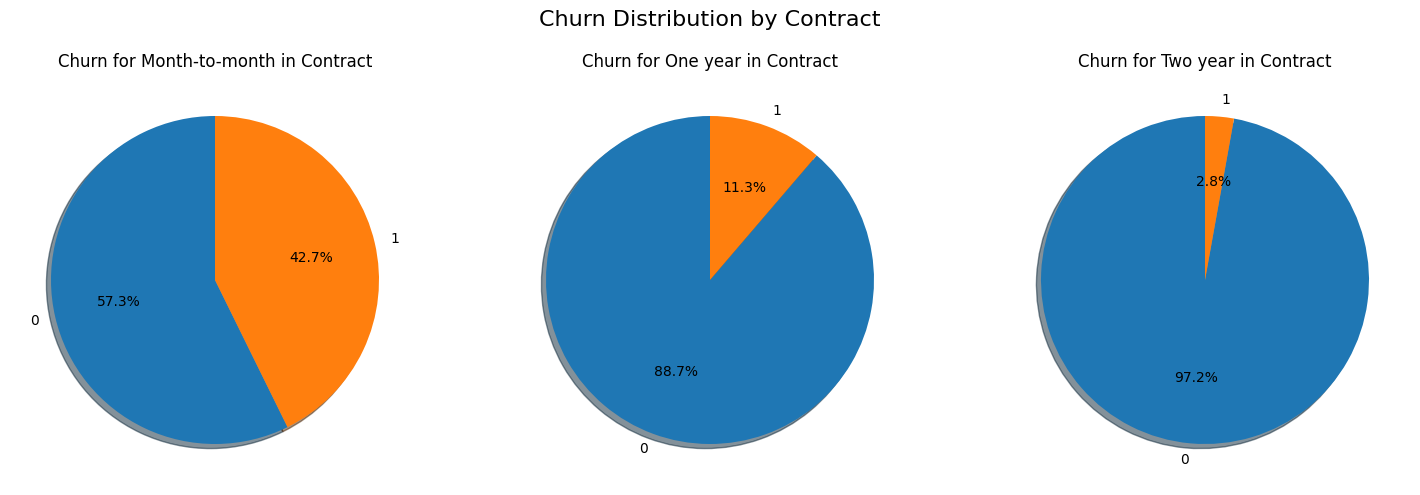

In [ ]:
plot_churn_by_category(df_labeled, 'Contract')

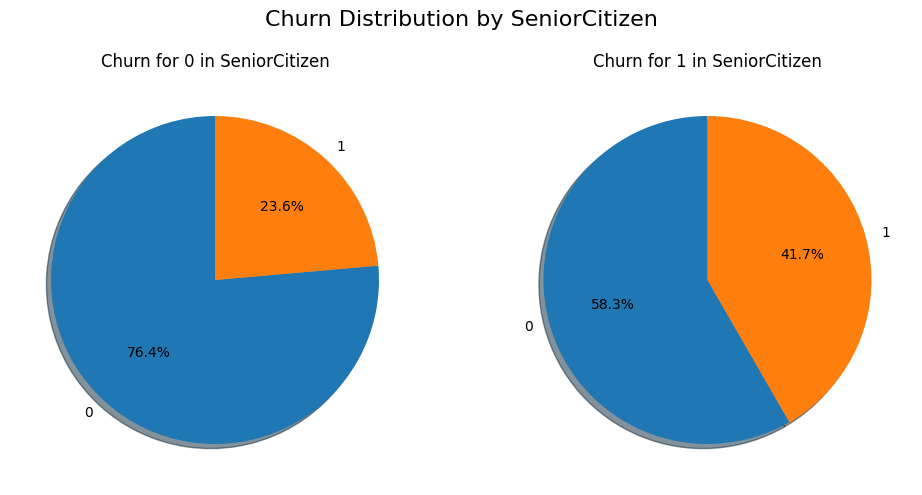

In [ ]:
plot_churn_by_category(df_labeled, 'SeniorCitizen')

# 10. Encode Categorical Data

In [ ]:
#Step 10: Encode Categorical data----------------------------------------------------------------

#Incase if user_id is an object:
df_updated = df_labeled.copy()
identity = df_labeled["customerID"]
response = df_labeled["Churn"]

df_updated = df_updated.drop(columns=["customerID", "Churn"])

# convert rest of categorical variable into dummy
categorical_cols = df_updated.select_dtypes(include=['object', 'category']).columns
df_updated = pd.get_dummies(df_updated, columns=categorical_cols, drop_first=True)

# Ubah semua kolom bertipe bool ke 0 dan 1
df_updated = df_updated.astype({col: int for col in df_updated.select_dtypes(include='bool').columns})

#Rejoin userid to dataset (column concatenation)

df_updated = pd.concat([df_updated, response, identity], axis = 1)

In [ ]:
df_updated.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn,customerID
0,0,0,1,0,1,0,1,29.85,30.0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,7590-VHVEG
1,1,0,0,0,34,1,0,56.95,1890.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,5575-GNVDE
2,1,0,0,0,2,1,1,53.85,108.0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,3668-QPYBK
3,1,0,0,0,45,0,0,42.30,1841.0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,7795-CFOCW
4,0,0,0,0,2,1,1,70.70,152.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,9237-HQITU


# 11. Split Dataset into Dependent and Independent Variables

In [ ]:
#Step 11: Split dataset into dependent and independent variables-----------------------------------

#identify response variable & removing identifier:
y = df_updated['Churn']
x = df_updated.drop(columns=['Churn','customerID'])

## 12. Generate training and test datasets of dependent and independent variables


In [ ]:
#Step 12: Generate training and test datasets of dependent and independent variables-----------------
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    stratify=y,
    test_size = 0.2,
    random_state = 0)

#to resolve any class imbalance - use stratify parameter.

print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (5634, 30)
Number transactions y_train dataset:  (5634,)
Number transactions X_test dataset:  (1409, 30)
Number transactions y_test dataset:  (1409,)


In [ ]:

print('Raw Data Target Percentage')
print('Churn : {}'.format(y.value_counts()[1]/y.value_counts().sum()*100))
print('Not Churn : {}'.format(y.value_counts()[0]/y.value_counts().sum()*100))

Raw Data Target Percentage
Churn : 26.536987079369588
Not Churn : 73.4630129206304


## 14. Feature Scaling

In [ ]:
# Step 14: Feature Scaling-----------------------------------------------------------------------

sc_X = StandardScaler()
X_train2 = pd.DataFrame(sc_X.fit_transform(X_train))
X_train2.columns = X_train.columns.values
X_train2.index = X_train.index.values
X_train = X_train2

X_test2 = pd.DataFrame(sc_X.transform(X_test))
X_test2.columns = X_test.columns.values
X_test2.index = X_test.index.values
X_test = X_test2


In [ ]:
X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2499,0.996103,-0.444067,-0.961343,1.545268,0.363266,0.327252,-1.203537,0.193982,0.283964,-0.327252,-0.847780,-0.872769,-0.529854,-0.529854,1.573414,-0.529854,1.383161,-0.529854,1.394673,-0.529854,-0.624290,-0.529854,1.278739,-0.529854,-0.792372,1.958584,-0.559447,-0.530678,-0.707107,1.825882
5807,0.996103,-0.444067,-0.961343,-0.647137,1.016103,0.327252,-1.203537,-1.515002,-0.515001,-0.327252,-0.847780,-0.872769,1.887311,1.887311,-0.635561,1.887311,-0.722982,1.887311,-0.717014,1.887311,-0.624290,1.887311,-0.782021,1.887311,-0.792372,-0.510573,1.787480,1.884380,-0.707107,-0.547680
5118,-1.003913,-0.444067,1.040211,-0.647137,0.404069,0.327252,0.830884,0.715987,0.654390,-0.327252,1.179551,1.145778,-0.529854,-0.529854,-0.635561,-0.529854,-0.722982,-0.529854,1.394673,-0.529854,1.601819,-0.529854,-0.782021,-0.529854,-0.792372,-0.510573,-0.559447,1.884380,-0.707107,-0.547680
275,0.996103,-0.444067,1.040211,-0.647137,-1.105616,0.327252,0.830884,0.699362,-0.822432,-0.327252,1.179551,1.145778,-0.529854,-0.529854,-0.635561,-0.529854,1.383161,-0.529854,-0.717014,-0.529854,1.601819,-0.529854,-0.782021,-0.529854,-0.792372,-0.510573,-0.559447,-0.530678,1.414214,-0.547680
1350,-1.003913,-0.444067,1.040211,-0.647137,1.424126,0.327252,-1.203537,0.042700,0.917459,-0.327252,1.179551,-0.872769,-0.529854,-0.529854,1.573414,-0.529854,1.383161,-0.529854,1.394673,-0.529854,-0.624290,-0.529854,-0.782021,-0.529854,-0.792372,-0.510573,1.787480,-0.530678,-0.707107,1.825882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712,-1.003913,-0.444067,-0.961343,-0.647137,-0.126361,0.327252,0.830884,-0.303086,-0.281655,-0.327252,1.179551,-0.872769,-0.529854,-0.529854,-0.635561,-0.529854,1.383161,-0.529854,-0.717014,-0.529854,-0.624290,-0.529854,-0.782021,-0.529854,-0.792372,1.958584,-0.559447,-0.530678,1.414214,-0.547680
1954,0.996103,-0.444067,-0.961343,-0.647137,-1.268825,0.327252,0.830884,0.368538,-0.967054,-0.327252,1.179551,1.145778,-0.529854,-0.529854,-0.635561,-0.529854,-0.722982,-0.529854,-0.717014,-0.529854,-0.624290,-0.529854,-0.782021,-0.529854,-0.792372,-0.510573,-0.559447,-0.530678,1.414214,-0.547680
525,0.996103,-0.444067,-0.961343,-0.647137,0.812091,0.327252,-1.203537,0.893867,1.101562,-0.327252,-0.847780,1.145778,-0.529854,-0.529854,1.573414,-0.529854,-0.722982,-0.529854,1.394673,-0.529854,-0.624290,-0.529854,1.278739,-0.529854,-0.792372,1.958584,-0.559447,-0.530678,1.414214,-0.547680
5748,-1.003913,-0.444067,-0.961343,-0.647137,-0.452779,0.327252,0.830884,1.179806,-0.116184,-0.327252,1.179551,1.145778,-0.529854,-0.529854,-0.635561,-0.529854,1.383161,-0.529854,-0.717014,-0.529854,-0.624290,-0.529854,1.278739,-0.529854,1.262034,-0.510573,-0.559447,1.884380,-0.707107,-0.547680


## 15. Model Selection

### Step 15.1: Compare Baseline Classification Algorithms (before SMOTE)

In [ ]:
#Step 15.1: Compare Baseline Classification Algorithms - First Iteration
#Using Accuracy and ROC AUC Mean Metrics


#--Step 15.1.1. Logistic Regression-----------------

# Fitting Logistic Regression to the Training set
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=0)
log_reg.fit(X_train, y_train)

# Predicting the Test set results
y_pred_log = log_reg.predict(X_test)
y_prob_log = log_reg.predict_proba(X_test)[:, 1]

#Evaluate results
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))
print("Classification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


#Step 15.1.2. Decision Tree--------------------------------------------

# Fitting Decision Tree to the Training set:
tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train, y_train)

# Predicting the Test set results
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

#Evaluate results
print("\n🔹 Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("ROC AUC:", roc_auc_score(y_test, y_prob_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))


#Step 15.1.3. Random Forest--------------------------------------------

# Fitting Random Forest to the Training set:
rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf.fit(X_train, y_train)

# Predicting the Test set results
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

#Evaluate results
print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


🔹 Logistic Regression
Accuracy: 0.752306600425834
ROC AUC: 0.8512025627115143
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409

Confusion Matrix:
 [[758 277]
 [ 72 302]]

🔹 Decision Tree
Accuracy: 0.7430801987224982
ROC AUC: 0.6767999689994575
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.82      0.82      1035
           1       0.52      0.53      0.52       374

    accuracy                           0.74      1409
   macro avg       0.67      0.68      0.67      1409
weighted avg       0.75      0.74      0.74      1409

Confusion Matrix:
 [[848 187]
 [175 199]]

🔹 Random Forest
Accuracy: 0.7892122072391767
ROC AUC: 0.83046

In [ ]:
results = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_log),
        'ROC AUC': roc_auc_score(y_test, y_prob_log),
        'Precision': precision_score(y_test, y_pred_log),
        'Recall': recall_score(y_test, y_pred_log),
        'F1 Score': f1_score(y_test, y_pred_log),
        'F2 Score': fbeta_score(y_test, y_pred_log, beta=2)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_tree),
        'ROC AUC': roc_auc_score(y_test, y_prob_tree),
        'Precision': precision_score(y_test, y_pred_tree),
        'Recall': recall_score(y_test, y_pred_tree),
        'F1 Score': f1_score(y_test, y_pred_tree),
        'F2 Score': fbeta_score(y_test, y_pred_tree, beta=2)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'ROC AUC': roc_auc_score(y_test, y_prob_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1 Score': f1_score(y_test, y_pred_rf),
        'F2 Score': fbeta_score(y_test, y_pred_rf, beta=2)
    }
])



results = results.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)


print (results)

                 Model  Accuracy   ROC AUC  Precision    Recall  F1 Score  \
2        Random Forest  0.789212  0.830466   0.641026  0.467914  0.540958   
0  Logistic Regression  0.752307  0.851203   0.521589  0.807487  0.633788   
1        Decision Tree  0.743080  0.676800   0.515544  0.532086  0.523684   

   F2 Score  
2  0.494630  
0  0.727711  
1  0.528693  


### Step 15.2.  Visualize Classification Algorithms Accuracy Comparisons

/tmp/ipython-input-3911351865.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=sorted_results, palette='viridis')


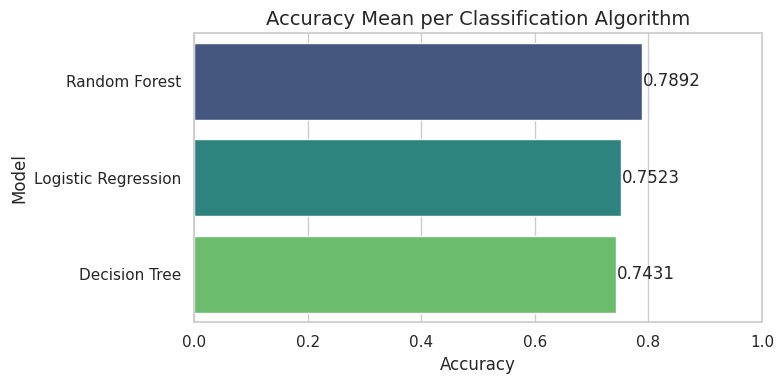

In [ ]:
#Step 15.2.  Visualize Classification Algorithms Accuracy Comparisons:-----------------------------------


#Using Accuracy Mean:

import seaborn as sns
# Set style
sns.set(style="whitegrid")

# Urutkan data berdasarkan Accuracy Mean
sorted_results = results.sort_values(by='Accuracy', ascending=False)

# Plot barplot
plt.figure(figsize=(8, 4))
sns.barplot(x='Accuracy', y='Model', data=sorted_results, palette='viridis')

# Tambahkan nilai di ujung bar
for index, value in enumerate(sorted_results['Accuracy']):
    plt.text(value + 0.001, index, f'{value:.4f}', va='center')

plt.title('Accuracy Mean per Classification Algorithm', fontsize=14)
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)  # karena accuracy antara 0 dan 1
plt.tight_layout()
plt.show()

/tmp/ipython-input-1333964783.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


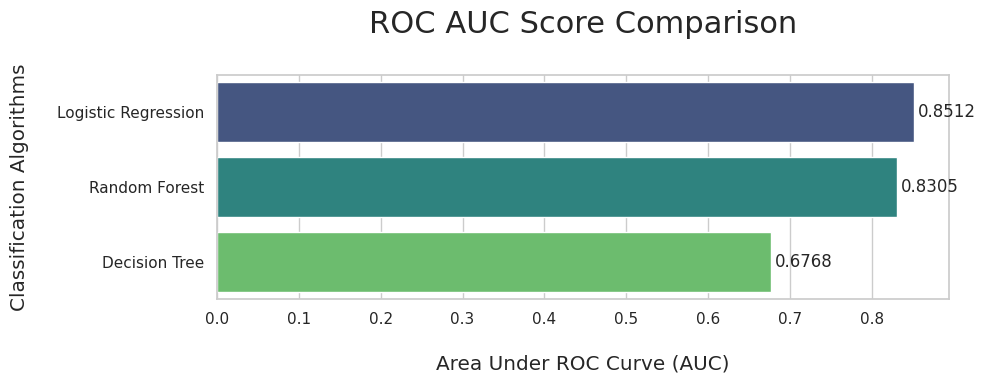

In [ ]:
#using Area under ROC Curve:


# Sort data berdasarkan ROC AUC Mean
sorted_auc = results.sort_values(by='ROC AUC', ascending=False)

# Set style
sns.set(style="whitegrid")

# Ukuran figure
plt.figure(figsize=(10, 4))

# Barplot untuk ROC AUC Mean
sns.barplot(
    x='ROC AUC',
    y='Model',
    data=sorted_auc,
    palette='viridis'
)

# Tambahkan nilai AUC di ujung bar
for index, value in enumerate(sorted_auc['ROC AUC']):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center')

# Label sumbu dan judul
plt.xlabel('\nArea Under ROC Curve (AUC)', fontstyle="normal", fontsize="large", fontfamily="sans-serif")
plt.ylabel('Classification Algorithms\n', fontstyle="normal", fontsize="large", fontfamily="sans-serif")
plt.title('ROC AUC Score Comparison\n', fontstyle="normal", fontsize=22, fontfamily="sans-serif")

# Menampilkan plot
plt.tight_layout()
plt.show()

### Step 15.3. SMOTE Oversampling

To maintain the integrity of model evaluation, oversampling was performed exclusively on the training folds post-splitting. Applying oversampling before cross-validation would introduce synthetic leakage and distort the validation set's native class distribution (74:26) into a balanced 50:50 split, leading to overly optimistic ROC-AUC scores.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report


# 2. Terapkan SMOTE hanya di training set
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 3. Latih model
model = RandomForestClassifier()
model.fit(X_train_sm, y_train_sm)

# 4. Evaluasi di test set asli
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1035
           1       0.62      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



### 15.4. Searching Optimum Number of Trees for Random Forest Model

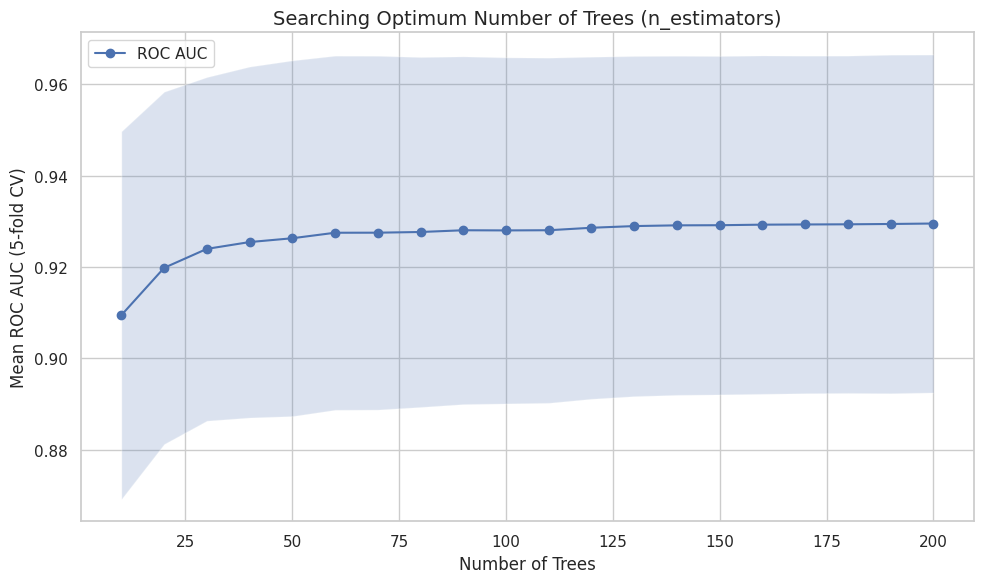

In [ ]:
# Range jumlah pohon yang ingin diuji
n_estimators_range = range(10, 210, 10)  # dari 10 sampai 200, step 10

# Simpan hasil
mean_scores = []
std_scores = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=0)
    # Gunakan ROC AUC sebagai metrik cross-validation
    scores = cross_val_score(rf, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())

# Plot hasilnya
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, mean_scores, marker='o', label='ROC AUC')
plt.fill_between(n_estimators_range,
                 np.array(mean_scores) - np.array(std_scores),
                 np.array(mean_scores) + np.array(std_scores),
                 alpha=0.2)
plt.title('Searching Optimum Number of Trees (n_estimators)', fontsize=14)
plt.xlabel('Number of Trees')
plt.ylabel('Mean ROC AUC (5-fold CV)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

**Graph Analysis:**

    * Rapid Initial Performance Gain: Increasing n_estimators from 10 to 30 results in a sharp rise in the ROC-AUC score, jumping from approximately 0.91 to over 0.925.

        - Meaning: Adding trees in the early stages significantly improves model performance.

    * Plateau Effect: Beyond n_estimators ≈ 60, the score curve begins to flatten, yielding only marginal performance gains.

    * Optimal Range: The ROC-AUC score stabilizes within the 0.927–0.928 range, reaching near-peak performance.

**Conclusion:**

Setting n_estimators between 60 and 100 provides the best balance between model accuracy and computational efficiency, as higher values yield negligible improvements while increasing training time.

In [ ]:
# Buat Fungsi
def search_optimum_n_estimators(X, y, scoring='roc_auc', cv=5,
                                 n_estimators_range=range(10, 210, 10), random_state=0):


    mean_scores = []
    std_scores = []

    for n in n_estimators_range:
        rf = RandomForestClassifier(n_estimators=n, random_state=random_state)
        scores = cross_val_score(rf, X, y, cv=cv, scoring=scoring)
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(n_estimators_range, mean_scores, marker='o', label=f'{scoring}')
    plt.fill_between(n_estimators_range,
                     np.array(mean_scores) - np.array(std_scores),
                     np.array(mean_scores) + np.array(std_scores),
                     alpha=0.2)
    plt.title(f'Searching Optimum Number of Trees ({scoring})', fontsize=14)
    plt.xlabel('Number of Trees (n_estimators)')
    plt.ylabel(f'Mean CV Score ({scoring})')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Return results
    return {
        'n_estimators': list(n_estimators_range),
        'mean_scores': mean_scores,
        'std_scores': std_scores
    }

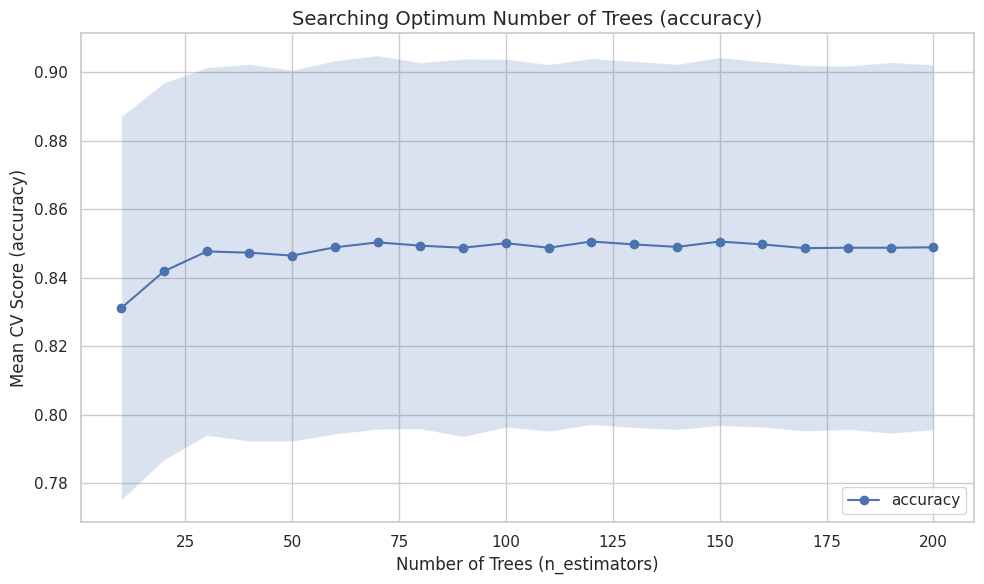

In [ ]:
# Check fungsi untuk accuracy
result_acc = search_optimum_n_estimators(
    X=X_train_sm,
    y=y_train_sm,
    scoring='accuracy',
    cv=5,
    n_estimators_range=range(10, 201, 10)
)

###Step 15.4. Compare Baseline Classification Algorithms (After SMOTE)

In [ ]:
#Step 15.4. Compare Baseline Classification Algorithms - Second Iteration-----------------------------
#--Step 15.4.1. Logistic Regression-----------------

# Fitting Logistic Regression to the Training set
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=0)
log_reg.fit(X_train_sm, y_train_sm)

# Predicting the Test set results
y_pred_sm_log = log_reg.predict(X_test)
y_prob_sm_log = log_reg.predict_proba(X_test)[:, 1]

#Evaluate results
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

print("🔹 Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_sm_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_sm_log))
print("Classification Report:\n", classification_report(y_test, y_pred_sm_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm_log))


#Step 15.4.2. Decision Tree--------------------------------------------

# Fitting Decision Tree to the Training set:
tree = DecisionTreeClassifier(criterion='entropy', random_state=0)
tree.fit(X_train_sm, y_train_sm)

# Predicting the Test set results
y_pred_sm_tree = tree.predict(X_test)
y_prob_sm_tree = tree.predict_proba(X_test)[:, 1]

#Evaluate results
print("\n🔹 Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_sm_tree))
print("ROC AUC:", roc_auc_score(y_test, y_prob_sm_tree))
print("Classification Report:\n", classification_report(y_test, y_pred_sm_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm_tree))


#Step 15.4.3. Random Forest--------------------------------------------

# Fitting Random Forest to the Training set:
rf = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=0)
rf.fit(X_train_sm, y_train_sm)

# Predicting the Test set results
y_pred_sm_rf = rf.predict(X_test)
y_prob_sm_rf = rf.predict_proba(X_test)[:, 1]

#Evaluate results
print("\n🔹 Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_sm_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_sm_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_sm_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sm_rf))

🔹 Logistic Regression
Accuracy: 0.758694109297374
ROC AUC: 0.8502053785941254
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

Confusion Matrix:
 [[770 265]
 [ 75 299]]

🔹 Decision Tree
Accuracy: 0.7210787792760823
ROC AUC: 0.6523831667054174
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81      1035
           1       0.48      0.50      0.49       374

    accuracy                           0.72      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.72      0.72      1409

Confusion Matrix:
 [[829 206]
 [187 187]]

🔹 Random Forest
Accuracy: 0.7785663591199432
ROC AUC: 0.83379

##**Model Performance Analysis**
1. **Logistic Regression**
- Achieved the highest ROC AUC (0.85), indicating that the model has the strongest ability to distinguish between Class 0 and Class 1.
- Achieved a high recall for Class 1 (0.80), meaning the model successfully identifies most of the actual positive cases.
- However, the precision for Class 1 is relatively low (0.53), indicating that a considerable number of cases predicted as positive are actually negative.
- Overall, Logistic Regression is particularly suitable when minimizing false negatives and detecting positive cases is the primary objective.
2. **Decision Tree**
- Produced the lowest ROC AUC (0.65) among the three models, indicating relatively weak class separation.
- Both precision and recall for Class 1 are relatively low, suggesting that the model is less effective at correctly identifying positive cases.
- Overall, the Decision Tree shows the weakest performance compared with Logistic Regression and Random Forest.
3. **Random Forest**
- Achieved the highest accuracy (0.78), indicating strong overall classification performance.
- Obtained the highest precision for Class 1 (0.59), meaning that its positive predictions are more reliable than those of the other models.
- Achieved a high ROC AUC (0.83), which is close to Logistic Regression (0.85), demonstrating strong discriminatory ability.
- However, its recall for Class 1 (0.56) is considerably lower than Logistic Regression (0.80), meaning that it misses more actual positive cases.
- Overall, Random Forest provides a more balanced performance, particularly when both overall accuracy and precision are important.

**Overall Conclusion**

Logistic Regression demonstrates the strongest ability to identify Class 1 cases, as reflected by its highest recall (0.80) and ROC AUC (0.85). Random Forest provides a more balanced performance, achieving the highest accuracy (0.78) and precision for Class 1 (0.59), while maintaining a high ROC AUC (0.83). Decision Tree shows the weakest overall performance. Therefore, the choice between Logistic Regression and Random Forest should depend on the business objective: Logistic Regression is preferable when identifying as many positive cases as possible is the priority, while Random Forest may be more appropriate when overall performance and the reliability of positive predictions are more important.

###Step 15.5. Visualize the results and compare the baseline algorithms

In [ ]:

#Step 15.5. Visualize the results and compare the baseline algorithms----------------------------------

# =======================================================================================================================
#Sort results based on the right classification metric:
#(Accuracy/ROC_AUC / Precision/Recall/F1/F2 scores)

#Since we have class imbalance. When we look into the business challenge,
# our false negatives will be costly and hence we need to Keep an eye onto the Precision, Recall & F2 score besides accuracy
# =======================================================================================================================

results_sm = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': accuracy_score(y_test, y_pred_sm_log),
        'ROC AUC': roc_auc_score(y_test, y_prob_sm_log),
        'Precision': precision_score(y_test, y_pred_sm_log),
        'Recall': recall_score(y_test, y_pred_sm_log),
        'F1 Score': f1_score(y_test, y_pred_sm_log),
        'F2 Score': fbeta_score(y_test, y_pred_sm_log, beta=2)
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_sm_tree),
        'ROC AUC': roc_auc_score(y_test, y_prob_sm_tree),
        'Precision': precision_score(y_test, y_pred_sm_tree),
        'Recall': recall_score(y_test, y_pred_sm_tree),
        'F1 Score': f1_score(y_test, y_pred_sm_tree),
        'F2 Score': fbeta_score(y_test, y_pred_sm_tree, beta=2)
    },
    {
        'Model': 'Random Forest',
        'Accuracy': accuracy_score(y_test, y_pred_sm_rf),
        'ROC AUC': roc_auc_score(y_test, y_prob_sm_rf),
        'Precision': precision_score(y_test, y_pred_sm_rf),
        'Recall': recall_score(y_test, y_pred_sm_rf),
        'F1 Score': f1_score(y_test, y_pred_sm_rf),
        'F2 Score': fbeta_score(y_test, y_pred_sm_rf, beta=2)
    }
])



results_sm = results_sm.sort_values(["Precision", "Recall", "F2 Score"], ascending = False)


print (results_sm)

                 Model  Accuracy   ROC AUC  Precision    Recall  F1 Score  \
2        Random Forest  0.778566  0.833792   0.587079  0.558824  0.572603   
0  Logistic Regression  0.758694  0.850205   0.530142  0.799465  0.637527   
1        Decision Tree  0.721079  0.652383   0.475827  0.500000  0.487614   

   F2 Score  
2  0.564255  
0  0.725728  
1  0.494971  


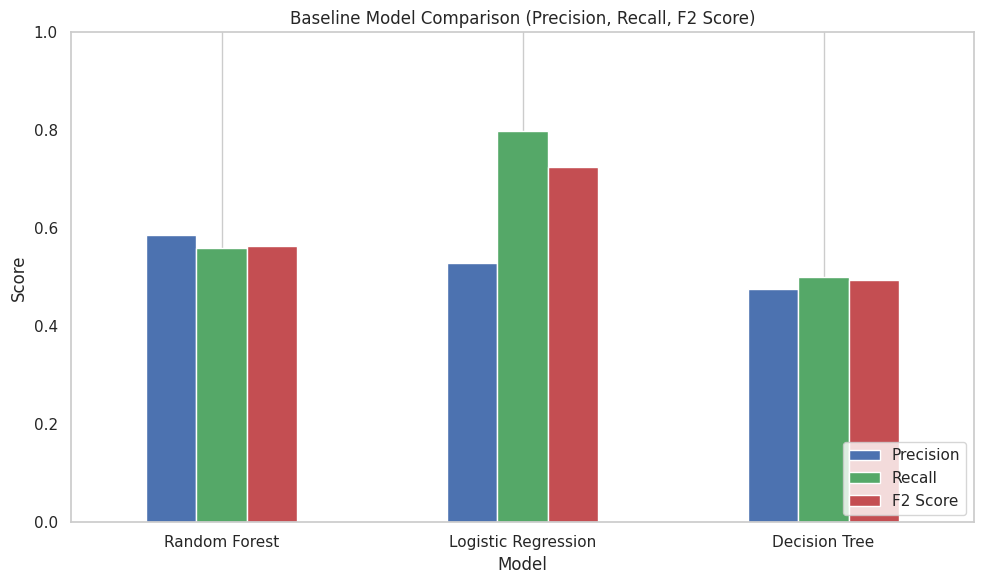

In [ ]:
# Plot Precision, Recall, F2 Score
metrics_to_plot = ["Precision", "Recall", "F2 Score"]
colors = ["#4c72b0", "#55a868", "#c44e52"]

results_plot = results_sm.set_index("Model")[metrics_to_plot]

results_plot.plot(kind="bar", figsize=(10, 6), color=colors)
plt.title("Baseline Model Comparison (Precision, Recall, F2 Score)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()



## 16. Train & Evaluate Chosen Model

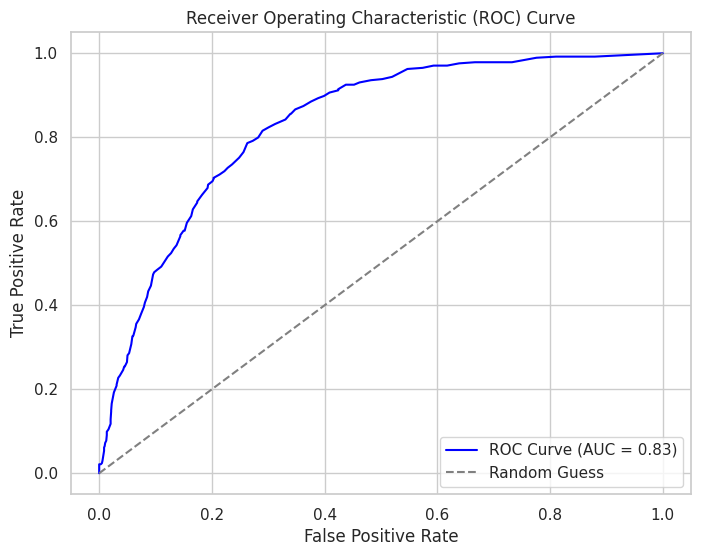

Confusion Matrix:
[[893 142]
 [171 203]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1035
           1       0.59      0.54      0.56       374

    accuracy                           0.78      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC Score: 0.8305


In [ ]:

#Step 16: Train & evaluate Chosen Model---------------------------------------------


# Fit Chosen Model on the Training dataset:
model = RandomForestClassifier(n_estimators=100, random_state=42)  # Atur model & hyperparameter
model.fit(X_train_sm, y_train_sm)


# Predict the Test set results
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluate the Model Using ROC Graph
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#Evaluate Model Results on Test Set:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc:.4f}")

In [ ]:
# Evaluate the model using ROC Graph


ROC Curve:

- Garis biru menggambarkan hubungan antara:

      - True Positive Rate (TPR) = Sensitivitas

      - False Positive Rate (FPR) = 1 - Spesifisitas

- ROC curve ini melengkung tajam ke atas kiri, artinya model ini mampu membedakan kelas positif dan negatif dengan baik.

##Analysis

---



In [ ]:
print ('Result Before Oversampling : ')
print (results)
print ('  ')
print ('Result After Oversampling : ')
print (results_sm)

Result Before Oversampling : 
                 Model  Accuracy   ROC AUC  Precision    Recall  F1 Score  \
2        Random Forest  0.789212  0.830466   0.641026  0.467914  0.540958   
0  Logistic Regression  0.752307  0.851203   0.521589  0.807487  0.633788   
1        Decision Tree  0.743080  0.676800   0.515544  0.532086  0.523684   

   F2 Score  
2  0.494630  
0  0.727711  
1  0.528693  
  
Result After Oversampling : 
                 Model  Accuracy   ROC AUC  Precision    Recall  F1 Score  \
2        Random Forest  0.778566  0.833792   0.587079  0.558824  0.572603   
0  Logistic Regression  0.758694  0.850205   0.530142  0.799465  0.637527   
1        Decision Tree  0.721079  0.652383   0.475827  0.500000  0.487614   

   F2 Score  
2  0.564255  
0  0.725728  
1  0.494971  


###**Modeling Results Analysis: Before vs. After Oversampling**

1. **Accuracy**

**Before Oversampling:**

**Random Forest** achieved the highest accuracy at 0.789, indicating the strongest overall classification performance among the three models.

**After Oversampling:**

- Model accuracy generally decreased slightly.
- Random Forest decreased from 0.789 to 0.779.
- Decision Tree decreased from 0.743 to 0.721.
- This slight decrease is expected in some imbalanced classification problems because oversampling shifts the model's focus toward the minority class rather than optimizing overall accuracy.

**Interpretation:**
Although accuracy decreased slightly after oversampling, this does not necessarily indicate poorer model performance. Other metrics, particularly Recall and F1 Score for the minority class, should also be considered.

2. **ROC AUC**
- **Logistic Regression** achieved the highest ROC AUC both before (0.851) and after oversampling (0.850).
- The very small change indicates that Logistic Regression maintained stable discriminatory performance after oversampling.
- **Random Forest** showed a slight improvement in ROC AUC, increasing from 0.830 to 0.834.
- In contrast, **Decision Tree** experienced a decrease from 0.677 to 0.652.

**Conclusion:**

Logistic Regression demonstrated the most consistent ROC AUC performance, maintaining the highest score before and after oversampling. This indicates that the model has strong and stable capability to distinguish between classes.

3.  **Precision, Recall, and F1 Score**

**Before Oversampling:**

- **Random Forest** achieved higher precision for Class 1 but had lower recall compared with Logistic Regression.
- **Logistic Regression** achieved the highest recall for Class 1 at 0.807, indicating that it was better at identifying actual positive cases.
- **Logistic Regression** also achieved a relatively strong F1 Score of 0.633, reflecting a reasonable balance between precision and recall.

**After Oversampling:**

- **Logistic Regression** maintained a high recall for Class 1 at 0.799 and its F1 Score improved slightly from 0.633 to 0.638.
- R**andom Forest** showed a notable improvement in recall, increasing from 0.468 to 0.559.
- Its F1 Score also improved from 0.541 to 0.573.

**Conclusion:**

Oversampling improved the ability of Random Forest to identify minority-class cases, as reflected by the increase in Recall and F1 Score. Logistic Regression, however, remained the most balanced model, maintaining high recall while achieving a slight improvement in F1 Score.

4. **F2 Score – Emphasis on Recall**

The **F2 Score** gives greater importance to Recall than Precision, making it useful when correctly identifying positive cases is a priority.

**After oversampling:**

- **Class 2**: F2 Score increased from 0.495 to 0.564, indicating improved detection of this class.
- **Class 0**: F2 Score remained almost unchanged, decreasing slightly from 0.728 to 0.726.
- **Class 1**: F2 Score decreased from 0.529 to 0.495, indicating a slight reduction in recall-oriented performance for this class.

**Conclusion:**

The impact of oversampling varied across classes. It substantially improved the F2 Score for Class 2, while performance for Class 0 remained relatively stable. However, Class 1 experienced a slight decline. Therefore, oversampling did not uniformly improve performance across all classes and should be evaluated based on the specific class and business objective.

## **Overall Conclusion**

The comparison between models before and after oversampling shows that oversampling had mixed effects on model performance. While overall accuracy decreased slightly, Random Forest benefited from improved Recall and F1 Score, particularly for the minority class. Logistic Regression remained the most stable model, achieving the highest ROC AUC both before and after oversampling and maintaining a high Recall for Class 1.

Therefore, model selection should not rely solely on Accuracy. For imbalanced classification problems, Recall, F1 Score, F2 Score, and ROC AUC provide additional insights into the model's ability to identify minority-class cases. Based on these results, Logistic Regression appears to be the most consistent model, while Random Forest shows meaningful improvement after oversampling.